In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import cuda

img = plt.imread("photo.jpg")
h, w, _ = img.shape

imgLow = (img * 0.4 + 80).astype(np.uint8)
print(img.shape, "| original:", img.min(), "-", img.max(), "| low contrast:", imgLow.min(), "-", imgLow.max())


(800, 1200, 3) | original: 0 - 255 | low contrast: 80 - 182


In [3]:
start = time.time()

grayCPU = np.zeros((h, w), np.uint8)
for y in range(h):
    for x in range(w):
        grayCPU[y, x] = (int(imgLow[y, x, 0]) + int(imgLow[y, x, 1]) + int(imgLow[y, x, 2])) // 3

vmin = 255
vmax = 0
for y in range(h):
    for x in range(w):
        v = int(grayCPU[y, x])
        if v < vmin:
            vmin = v
        if v > vmax:
            vmax = v

stretchCPU = np.zeros((h, w), np.uint8)
for y in range(h):
    for x in range(w):
        stretchCPU[y, x] = (int(grayCPU[y, x]) - vmin) * 255 // (vmax - vmin)

cpuTime = time.time() - start
print("CPU time:", cpuTime, "s | min:", vmin, "| max:", vmax)


CPU time: 2.0191380977630615 s | min: 80 | max: 182


In [4]:
@cuda.jit
def grayscale2d(src, dst):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < src.shape[0] and x < src.shape[1]:
        dst[y, x] = (src[y, x, 0] + src[y, x, 1] + src[y, x, 2]) // 3


@cuda.jit
def reduce_minmax(srcMin, srcMax, dstMin, dstMax):
    sMin = cuda.shared.array(1024, np.uint8)
    sMax = cuda.shared.array(1024, np.uint8)
    tid = cuda.threadIdx.x
    i = tid + cuda.blockIdx.x * cuda.blockDim.x

    if i < srcMin.shape[0]:
        sMin[tid] = srcMin[i]
        sMax[tid] = srcMax[i]
    else:
        sMin[tid] = 255
        sMax[tid] = 0
    cuda.syncthreads()

    s = cuda.blockDim.x // 2
    while s > 0:
        if tid < s:
            sMin[tid] = min(sMin[tid], sMin[tid + s])
            sMax[tid] = max(sMax[tid], sMax[tid + s])
        cuda.syncthreads()
        s = s // 2

    if tid == 0:
        dstMin[cuda.blockIdx.x] = sMin[0]
        dstMax[cuda.blockIdx.x] = sMax[0]


@cuda.jit
def stretch(src, dst, vmin, vmax):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < src.shape[0] and x < src.shape[1]:
        dst[y, x] = (src[y, x] - vmin) * 255 // (vmax - vmin)


In [5]:
def gpu_minmax(devData, blockSize):
    devMin = devData
    devMax = devData
    n = devData.shape[0]
    while n > 1:
        nBlocks = (n + blockSize - 1) // blockSize
        outMin = cuda.device_array(nBlocks, np.uint8)
        outMax = cuda.device_array(nBlocks, np.uint8)
        reduce_minmax[nBlocks, blockSize](devMin, devMax, outMin, outMax)
        devMin = outMin
        devMax = outMax
        n = nBlocks
    return int(devMin.copy_to_host()[0]), int(devMax.copy_to_host()[0])


def gpu_stretch(bx, by):
    grid = ((w + bx - 1) // bx, (h + by - 1) // by)
    grayscale2d[grid, (bx, by)](devLow, devGray)
    vmin, vmax = gpu_minmax(devGray.reshape(h * w), bx * by)
    stretch[grid, (bx, by)](devGray, devOut, vmin, vmax)
    cuda.synchronize()
    return vmin, vmax


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 15 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


GPU min/max: 80 182 | CPU min/max: 80 182
Max diff with CPU: 0


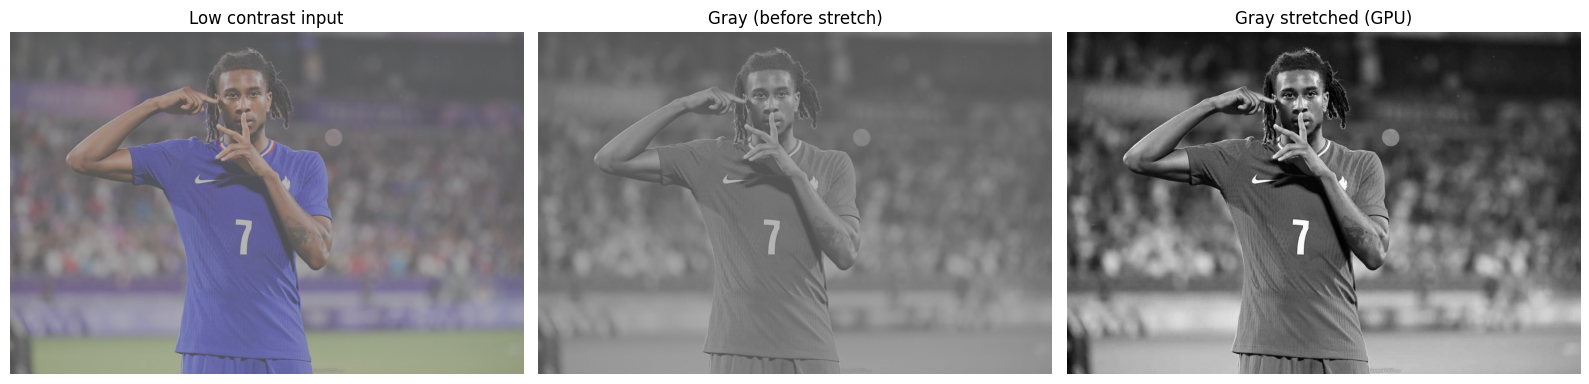

In [6]:
devLow = cuda.to_device(imgLow)
devGray = cuda.device_array((h, w), np.uint8)
devOut = cuda.device_array((h, w), np.uint8)

vminGPU, vmaxGPU = gpu_stretch(16, 16)
stretchGPU = devOut.copy_to_host()

print("GPU min/max:", vminGPU, vmaxGPU, "| CPU min/max:", vmin, vmax)
print("Max diff with CPU:", np.abs(stretchGPU.astype(int) - stretchCPU.astype(int)).max())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].imshow(imgLow)
axes[0].set_title("Low contrast input")
axes[1].imshow(grayCPU, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Gray (before stretch)")
axes[2].imshow(stretchGPU, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Gray stretched (GPU)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("results.png")
plt.show()


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 59 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


8 x 8 | GPU time: 0.002026867866516113 s | speedup: 996.1863479703105
16 x 8 | GPU time: 0.0013302087783813477 s | speedup: 1517.9106697972863
16 x 16 | GPU time: 0.0009588956832885742 s | speedup: 2105.691091275268
32 x 16 | GPU time: 0.000944054126739502 s | speedup: 2138.794842978546
32 x 32 | GPU time: 0.0007417559623718262 s | speedup: 2722.105652250775


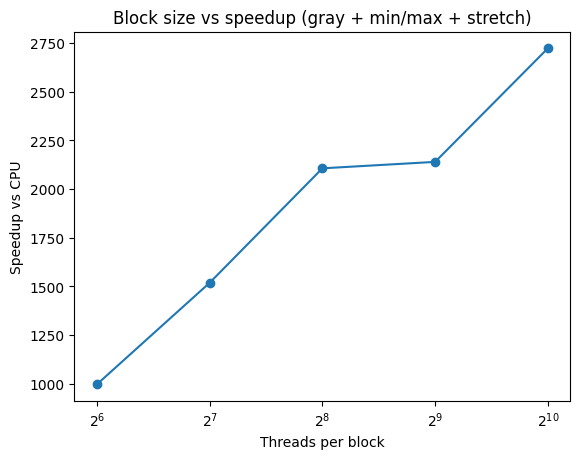

In [7]:
def measure(bx, by):
    gpu_stretch(bx, by)
    start = time.time()
    for r in range(20):
        gpu_stretch(bx, by)
    return (time.time() - start) / 20

blocks2D = [(8, 8), (16, 8), (16, 16), (32, 16), (32, 32)]
threads = []
speedups = []

for bx, by in blocks2D:
    t = measure(bx, by)
    threads.append(bx * by)
    speedups.append(cpuTime / t)
    print(bx, "x", by, "| GPU time:", t, "s | speedup:", cpuTime / t)

plt.plot(threads, speedups, marker="o")
plt.xscale("log", base=2)
plt.xlabel("Threads per block")
plt.ylabel("Speedup vs CPU")
plt.title("Block size vs speedup (gray + min/max + stretch)")
plt.savefig("blocksize_vs_speedup.png")
plt.show()
